# Python 编程实例

## 📦 标准库列表

- [标准库概览](https://www.runoob.com/python3/python3-stdlib.html)
- [open 方法](https://www.runoob.com/python3/python3-file-methods.html)
- [os 模块](https://www.runoob.com/python3/python3-os-file-methods.html)
- sys 模块
- psutil 模块
- subprocess 模块
- io 模块
- importlib 模块
- time 模块
- socket 模块
- IPython 模块
- math 模块

## 字符串表示字面义

In [1]:
word0 = r"python3\n"        # r 表示 raw，返回字符串字面义
word1 = "python3\n"         # 返回字符串并解释换行符
print(word0)
print(word1.strip(), "\n")  # 去除原字符串尾部换行符，再额外添加换行符

python3\n
python3 



## 加载与设置图片

In [19]:
from IPython import display

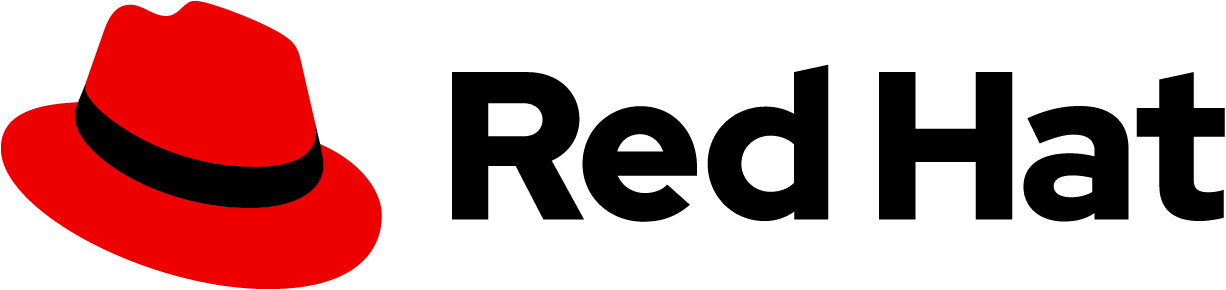

In [3]:
display.Image("images/redhat.png", width=300, height=150)

## 二进制数据输入与输出

In [4]:
import sys

data = b"hello world"                 # b 代表 binary 二进制
print(sys.stdout.buffer.write(data))  # JupyterLab 中无法返回结果，iPython 中可正常输出。

AttributeError: 'OutStream' object has no attribute 'buffer'

In [5]:
import io

#result = io.BytesIO(b"helloworld")
result = io.BytesIO(b"helloworld")  # 输出二进制字节流数据
output = result.read()

print(output)                      # 输出原始的字节
print(output.decode())             # 输出字节的文本

b'helloworld'
helloworld


## 文本数据、UTF-8 字节与 base64 编码转换

In [1]:
import base64

In [2]:
text = "如何理解 Embedding？"

In [3]:
# 编码过程：原始文本 > UTF-8 字节 > base64 编码
bytes_encode = text.encode('utf-8')
b64_encode = base64.b64encode(bytes_encode).decode('ascii')
print(b64_encode)

5aaC5L2V55CG6KejIEVtYmVkZGluZ++8nw==


In [4]:
# 解码过程：UTF-8 字节 > 原始文本
bytes_decode = base64.b64decode(b64_encode)
origin = bytes_decode.decode('utf-8')
print(origin)

如何理解 Embedding？


## 模块验证

In [7]:
# Python 模块检测脚本
import importlib, subprocess, sys

def ensure_module(module_name, package_name=None):
    """
    功能：检查指定模块是否存在，若不存在进行安装。

    参数：
      - module_name:  默认安装模块名称
      - package_name: 指定安装模块名称
    """
    if package_name is None:
        package_name = module_name

    try:
        if importlib.util.find_spec(module_name) is not None:    # 查看指定模块的加载信息与路径
            importlib.import_module(module_name)                 # 加载模块
            print(f"{module_name} 模块导入成功...")
            return True
    except:
        print(f"{module_name} 模块未找到，尝试安装 {package_name}...")
        try:
            subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])    # 运行命令安装
            print(f"{module_name} 模块安装成功...")
            return True
        except subprocess.CalledProcessError as e:
            print(f"{module_name} 模块安装失败：{e}")
            return False

ensure_module("numpy")
ensure_module("pandas")
ensure_module("PIL", "Pillow")

numpy 模块导入成功...
pandas 模块导入成功...
PIL 模块导入成功...


True

In [5]:
# 验证模块版本与入口文件
import numpy, openai, faiss, pypdf

print(f"numpy 版本 : {numpy.__version__:10s} | numpy 路径 ：{numpy.__file__}")
print(f"openai 版本: {openai.__version__:10s} | openai 路径：{openai.__file__}")
print(f"faiss 版本 : {faiss.__version__:10s} | faiss 路径 ：{faiss.__file__}")
print(f"pypdf 版本 : {pypdf.__version__:10s} | pypdf 路径 ：{pypdf.__file__}")

numpy 版本 : 2.4.2      | numpy 路径 ：/home/godev/backup/llm-aiops/lib/python3.12/site-packages/numpy/__init__.py
openai 版本: 1.109.1    | openai 路径：/home/godev/backup/llm-aiops/lib/python3.12/site-packages/openai/__init__.py
faiss 版本 : 1.13.2     | faiss 路径 ：/home/godev/backup/llm-aiops/lib/python3.12/site-packages/faiss/__init__.py
pypdf 版本 : 6.7.3      | pypdf 路径 ：/home/godev/backup/llm-aiops/lib/python3.12/site-packages/pypdf/__init__.py


## 显示当前运行路径

In [7]:
import sys

print(sys.executable)

/home/godev/backup/llm-aiops/bin/python3


In [10]:
!python -c 'import sys; print(sys.executable)'    # 单行命令形式

/home/godev/backup/llm-aiops/bin/python


In [8]:
sys.executable?

Type:        str
String form: /home/godev/backup/llm-aiops/bin/python3
Length:      40
Docstring:  
str(object='') -> str
str(bytes_or_buffer[, encoding[, errors]]) -> str

Create a new string object from the given object. If encoding or
errors is specified, then the object must expose a data buffer
that will be decoded using the given encoding and error handler.
Otherwise, returns the result of object.__str__() (if defined)
or repr(object).
encoding defaults to sys.getdefaultencoding().
errors defaults to 'strict'.

## 判断文件或目录是否存在：标准库 os 和 pathlib

In [24]:
from pathlib import Path

files = ["/etc/hosts", "/etc/nsswitch.conf", "/etc/sysctl.conf"]
dirs = ["/mnt/tmp", "/etc/NetworkManager"]

def exists(path: list):
    for f in path:
        p = Path(f)
        if p.exists():
            if p.is_file():
                print(f"文件名：{f}")
            elif p.is_dir():
                print(f"目录名：{f}")
        else:
            print(f"不存在：{f}")

exists(files)
exists(dirs)

文件名：/etc/hosts
文件名：/etc/nsswitch.conf
文件名：/etc/sysctl.conf
不存在：/mnt/tmp
目录名：/etc/NetworkManager


In [31]:
# 方法1：os.path 模块（传统方式）
import os

path = "/etc/issue"

# 判断是否存在
print(os.path.exists(path))      # True / False

# 判断是否是文件
print(os.path.isfile(path))      # True

# 判断是否是目录
print(os.path.isdir(path))       # False

# 判断是否是绝对路径
print(os.path.isabs(path))       # True

# 判断是否是符号链接
print(os.path.islink(path))      # True / False

# 获取文件大小（字节）
print(os.path.getsize(path))     # 26 字节

True
True
False
True
False
26


In [32]:
# 方法2：pathlib 模块（推荐，Python 3.4+）
from pathlib import Path

p = Path("/etc/issue")

# 判断是否存在
print(p.exists())           # True / False

# 判断是否是文件
print(p.is_file())          # True

# 判断是否是目录
print(p.is_dir())           # False

# 判断是否是符号链接
print(p.is_symlink())       # True / False

# 判断是否是绝对路径
print(p.is_absolute())    # True

# 获取文件大小
print(p.stat().st_size)   # 26 字节

# 获取修改时间
print(p.stat().st_mtime)  # 1770362581.0

True
True
False
False
True
26
1770362581.0


## TCP 端口连接验证

In [35]:
import socket

def ensure_conn():
    line = input("请输入 [IPv4 地址]:[端口] ➡️ ")
    combine = line.split(':')       # 返回各个元素为字符串的列表
    combine[1] = int(combine[1])    # s.connect 方法使用元组作为参数，其第二个元素为整形数，因此需要转换。

    try:
        s = socket.socket(socket.AF_INET, socket.SOCK_STREAM)    # 初始化对象实例
        s.connect(tuple(combine))                                # 实参：元组参数
        print("套接字连接正确！")
    except ConnectionRefusedError as c:    # ConnectionRefusedError 对象
        print(f"套接字连接拒绝：{c}")
    except OSError as e:                   # OSError 对象
        print(f"套接字连接异常：{e}")

ensure_conn()

请输入 [IPv4 地址]:[端口] ➡️  192.168.110.203:8880


套接字连接正确！


## 浮点数指定位数

In [5]:
import math

print(f"圆周率保留 3 位小数：{math.pi:.3f}")        # f{} 格式化字符串输出
print("圆周率保留 2 位小时：", round(math.pi, 2))    # round 函数指定浮点数位数

圆周率保留 3 位小数：3.142
圆周率保留 2 位小时： 3.14


## Python 所有内置异常

In [2]:
print([ name for name in dir(__builtins__) if "Error" in name or "Exception" in name or "Warning" in name ])

['ArithmeticError', 'AssertionError', 'AttributeError', 'BaseException', 'BaseExceptionGroup', 'BlockingIOError', 'BrokenPipeError', 'BufferError', 'BytesWarning', 'ChildProcessError', 'ConnectionAbortedError', 'ConnectionError', 'ConnectionRefusedError', 'ConnectionResetError', 'DeprecationWarning', 'EOFError', 'EncodingWarning', 'EnvironmentError', 'Exception', 'ExceptionGroup', 'FileExistsError', 'FileNotFoundError', 'FloatingPointError', 'FutureWarning', 'IOError', 'ImportError', 'ImportWarning', 'IndentationError', 'IndexError', 'InterruptedError', 'IsADirectoryError', 'KeyError', 'LookupError', 'MemoryError', 'ModuleNotFoundError', 'NameError', 'NotADirectoryError', 'NotImplementedError', 'OSError', 'OverflowError', 'PendingDeprecationWarning', 'PermissionError', 'ProcessLookupError', 'RecursionError', 'ReferenceError', 'ResourceWarning', 'RuntimeError', 'RuntimeWarning', 'SyntaxError', 'SyntaxWarning', 'SystemError', 'TabError', 'TimeoutError', 'TypeError', 'UnboundLocalError', 

## Matplotlib 折线图绘制

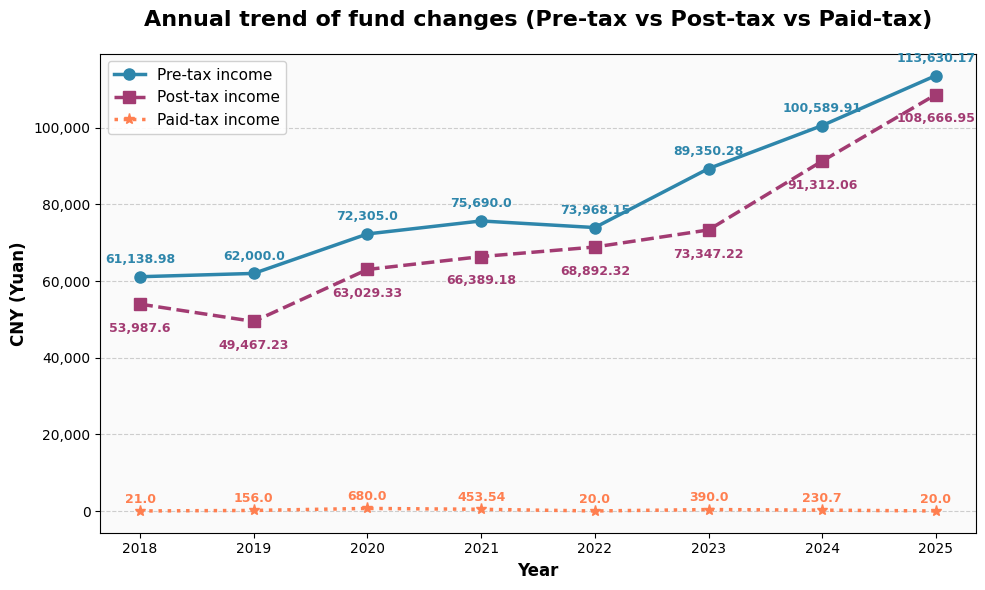

In [30]:
import matplotlib.pyplot as plt
import numpy as np

# 添加中文字体支持
#plt.rcParams['font.sans-serif'] = ['SimHei']    # 设置中文字体为黑体
#plt.rcParams['axes.unicode_minus'] = False      # 正常显示负号

# 设置数据：年份、税前所得额、税后所得额、应补税额
years = np.array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])
pre_tax = np.array([61138.98, 62000, 72305, 75690, 73968.15, 89350.28, 100589.91, 113630.17])
post_tax = np.array([53987.60, 49467.23, 63029.33, 66389.18, 68892.32, 73347.22, 91312.06, 108666.95])
paid_tax = np.array([21, 156, 680, 453.54, 20, 390, 230.7, 20])

# 创建图形
fig, ax = plt.subplots(figsize=(10, 6))

# 绘制三条折线（不包含对应数据）
line_pre = ax.plot(years, pre_tax, marker='o', markersize=8, linewidth=2.5, linestyle='-', 
                   color='#2E86AB', label='Pre-tax income')
line_post = ax.plot(years, post_tax, marker='s', markersize=8, linewidth=2.5, linestyle='--', 
                    color='#A23B72', label='Post-tax income')
line_paid = ax.plot(years, paid_tax, marker='*', markersize=8, linewidth=2.5, linestyle=':', 
                    color='#FF7F50', label='Paid-tax income')

# 添加折线上的数据标签
for i, (x, y1, y2, y3) in enumerate(zip(years, pre_tax, post_tax, paid_tax)):
    ax.annotate(f'{y1:,}', (x, y1), textcoords="offset points", xytext=(0,10), 
                ha='center', fontsize=9, color='#2E86AB', fontweight='bold')
    ax.annotate(f'{y2:,}', (x, y2), textcoords="offset points", xytext=(0,-20), 
                ha='center', fontsize=9, color='#A23B72', fontweight='bold')
    ax.annotate(f'{y3:,}', (x, y3), textcoords="offset points", xytext=(0,6),
                ha='center', fontsize=9, color='#FF7F50', fontweight='bold')

# 设置标题与标签
ax.set_title('Annual trend of fund changes (Pre-tax vs Post-tax vs Paid-tax)', 
             fontsize=16, fontweight='bold', pad=20)
ax.set_xlabel('Year', fontsize=12, fontweight='bold')
ax.set_ylabel('CNY (Yuan)', fontsize=12, fontweight='bold')

# 设置横坐标刻度
ax.set_xticks(years)
ax.set_xticklabels([ str(y) for y in years ])

# 设置纵坐标刻度（添加千位分隔符）
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{int(x):,}'))

# 添加网格线
#ax.grid(True, linestyle='--', alpha=0.6, axis='x')
ax.grid(True, linestyle='--', alpha=0.6, axis='y')

# 添加图例
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

# 设置背景色
ax.set_facecolor('#FAFAFA')
fig.patch.set_facecolor('white')

# 调整布局
plt.tight_layout()

# 保存图表
#plt.savefig('~/backup/annual_trend_of_fund_changes.png', dpi=150, bbox_inches='tight', 
#            facecolor='white', edgecolor='none')

plt.show()

## psutil 模块示例

In [92]:
import psutil, os

In [93]:
# 获取 CPU 逻辑核心数
print(f"CPU 逻辑核心数：{psutil.cpu_count(logical=True)}")
print(f"CPU 逻辑核心数：{os.cpu_count()}")

CPU 逻辑核心数：8
CPU 逻辑核心数：8


## 关于进程状态的探讨

&emsp;&emsp;Linux 中进程状态为 R 表示进程正在运行（**Running**）或处于单个 CPU 运行队列中（**Runnable**）。在 SMP（对称多处理，Symmetric Multi-Processing）架构中，每个 CPU 核心都对应一个 **运行队列（Run Queue）**，内核可将处于 R 状态的进程调度其中，参与 CPU 竞争。而处于 Sleeping 状态的进程处于等待被唤醒状态，在 **等待队列（Wait Queue）** 中，不参与 CPU 竞争。

<center><img src="images/SMP 架构下的进程状态分布.png" style="width:80%"></center>

## 测试 sleep 状态的进程在不同 CPU 核心间的调度迁移

In [1]:
import os
import time
import psutil

def track_cpu_migration(n: int):
    """
    功能：追踪 sleep 前后进程的 CPU 变化
    参数：sleep 的秒数（整型数）
    """
    pid = os.getpid()
    process = psutil.Process(pid)    # 初始化 process 对象实例

    initial_cpu = process.cpu_num()    # 当前进程运行的 CPU 编号
    print(f"Sleep 前：运行在 CPU {initial_cpu} 上")
    print(f"CPU 亲和性掩码：{process.cpu_affinity()}")

    print(f"Sleeping for {n} seconds...")
    time.sleep(n)    # 进程进入 sleep 状态，验证是否被迁移至其他 CPU 核心。

    final_cpu = process.cpu_num()
    print(f"Sleep 后：运行在 CPU {final_cpu} 上")

    if initial_cpu != final_cpu:
        print(f"⚠️  CPU 发生迁移: {initial_cpu} → {final_cpu}")
    else:
        print(f"✓  回到原 CPU {final_cpu}（巧合或调度器偏好）")

for i in range(3):
    print(f"\n===== 第 {i+1} 次测试 =====")
    track_cpu_migration(5)


===== 第 1 次测试 =====
Sleep 前：运行在 CPU 6 上
CPU 亲和性掩码：[0, 1, 2, 3, 4, 5, 6, 7]
Sleeping for 5 seconds...
Sleep 后：运行在 CPU 6 上
✓  回到原 CPU 6（巧合或调度器偏好）

===== 第 2 次测试 =====
Sleep 前：运行在 CPU 6 上
CPU 亲和性掩码：[0, 1, 2, 3, 4, 5, 6, 7]
Sleeping for 5 seconds...
Sleep 后：运行在 CPU 6 上
✓  回到原 CPU 6（巧合或调度器偏好）

===== 第 3 次测试 =====
Sleep 前：运行在 CPU 6 上
CPU 亲和性掩码：[0, 1, 2, 3, 4, 5, 6, 7]
Sleeping for 5 seconds...
Sleep 后：运行在 CPU 6 上
✓  回到原 CPU 6（巧合或调度器偏好）


In [12]:
import psutil

proc = psutil.Process(1)
print(proc.name())
print(proc.cpu_num())

systemd
1


## 获取当前各个进程所在的 CPU 核心与 CPU 使用率

In [97]:
import psutil

def proc_cpu_info(allin=None, pid=None):
    cpu_count = psutil.cpu_count(logical=True)
    print(f"当前系统的 CPU 逻辑核心数：{cpu_count}")
    print("-" * 50)
    print("各个进程所在的 CPU 核心与 CPU 使用率：\n")

    if pid is not None:
        print(f"进程 {pid} 状态如下：")
        proc = psutil.Process(pid)
        name = proc.name()
        cpu_num = proc.cpu_num()
        cpu_percent = proc.cpu_percent()
        print(f"| 进程名：{name:20s} | 进程号：{pid:6d} | 所在 CPU：{cpu_num:3d} | CPU 使用率：{cpu_percent}% |")
    elif allin == 'all' or allin == 'ALL':
        for proc in psutil.process_iter(['name', 'pid', 'cpu_num', 'cpu_percent']):
            try:
                info = proc.info
                cpu_num = info['cpu_num']
                if cpu_num is not None and 0 <= cpu_num < cpu_count:
                    yield print(f"| 进程名：{info['name'][:20]:30s} | 进程号：{info['pid']:6d} | 所在 CPU：{cpu_num:2d} | CPU 使用率：{info['cpu_percent']}% |")
            except (psutil.NoSuchProcess, psutil.AccessDenied):
                continue

in_all = input("请输入 ALL 或者 all，查询整体进程信息：")
in_pid = input("请输入查询的 PID：")

if in_all == 'ALL' or in_all == 'all':
    each_one = iter(proc_cpu_info(allin=in_all))
    next(each_one)
    next(each_one)
    next(each_one)
elif in_pid is not None:
    proc_cpu_info(pid=int(in_pid))                    

请输入 ALL 或者 all，查询整体进程信息： all
请输入查询的 PID： 


当前系统的 CPU 逻辑核心数：8
--------------------------------------------------
各个进程所在的 CPU 核心与 CPU 使用率：

| 进程名：systemd                        | 进程号：     1 | 所在 CPU： 2 | CPU 使用率：0.0% |
| 进程名：kthreadd                       | 进程号：     2 | 所在 CPU： 6 | CPU 使用率：0.0% |
| 进程名：pool_workqueue_relea           | 进程号：     3 | 所在 CPU： 0 | CPU 使用率：0.0% |
| 进程名：kworker/R-rcu_g                | 进程号：     4 | 所在 CPU： 0 | CPU 使用率：0.0% |
| 进程名：kworker/R-rcu_p                | 进程号：     5 | 所在 CPU： 0 | CPU 使用率：0.0% |
| 进程名：kworker/R-slub_                | 进程号：     6 | 所在 CPU： 0 | CPU 使用率：0.0% |


**格式化字符串（f-string）的格式说明符（format specifier）：**

| 格式符 | 作用 | 示例 |
| ----- | ----- | ----- |
| :6d | 整数占6位，右对齐 | 42 → "    42" |
| :06d | 整数占6位，补0 | 42 → "000042" |
| :<6d | 整数占6位，左对齐 | 42 → "42    " |
| :20s | 字符串占20位，左对齐 | "a" → "a                   " |
| :>20s | 字符串占20位，右对齐 | "a" → "                   a" |
| :.2f | 浮点数保留2位小数 | 3.14159 → "3.14" |
| :.2% | 百分比格式 | 0.1234 → "12.34%" |


## 获取各个 CPU 逻辑核心上运行的进程与总数

In [91]:
import psutil
import os

def cpu_proc_info(cal, map=None):
    cpu_count = psutil.cpu_count()
    cpu_proc_cal = { n:0 for n in range(cpu_count) }
    cpu_proc_map = { n:[] for n in range(cpu_count) }

    for proc in psutil.process_iter(['name', 'pid', 'cpu_num']):
        try:
            info = proc.info
            cpu_num = info['cpu_num']
            if cpu_num is not None and 0 <= cpu_num < cpu_count:    
                cpu_proc_cal[cpu_num] += 1
                #merge = '进程名：' + info['name'] + ' | ' + '进程号：' + str(info['pid'])
                merge = f"进程名：{info['name']:40s} | 进程号：{str(info['pid']):6s}"
                cpu_proc_map[cpu_num].append(merge)
        except (psutil.NoSuchProcess, psutil.AccessDenied):
            continue

    if cal == 'brief':
        return cpu_proc_cal
    elif cal is None and map == True:
        return cpu_proc_map
    elif cal == 'ALL' and map == True:
        return cpu_proc_cal, cpu_proc_map
        

print("各 CPU 上运行的进程数：")
print("-" * 30)
proc_all = cpu_proc_info('brief')
for x in list(proc_all.keys()):
    print(f"CPU 逻辑核心 {x} | 进程数：{proc_all[x]}")
    
print("\n各 CPU 上运行的具体进程：")
print("-" * 30)
proc_cal = cpu_proc_info(None, map=True)
i = 0
while i < os.cpu_count():
    print(f"\nCPU 逻辑核心 {i}：")
    for item in proc_cal[i]:
        print(f"  {item}")
    i += 1

各 CPU 上运行的进程数：
------------------------------
CPU 逻辑核心 0 | 进程数：61
CPU 逻辑核心 1 | 进程数：41
CPU 逻辑核心 2 | 进程数：62
CPU 逻辑核心 3 | 进程数：72
CPU 逻辑核心 4 | 进程数：45
CPU 逻辑核心 5 | 进程数：36
CPU 逻辑核心 6 | 进程数：48
CPU 逻辑核心 7 | 进程数：48

各 CPU 上运行的具体进程：
------------------------------

CPU 逻辑核心 0：
  进程名：pool_workqueue_release                   | 进程号：3     
  进程名：kworker/R-rcu_g                          | 进程号：4     
  进程名：kworker/R-rcu_p                          | 进程号：5     
  进程名：kworker/R-slub_                          | 进程号：6     
  进程名：kworker/R-netns                          | 进程号：7     
  进程名：kworker/0:0H-events_highpri              | 进程号：9     
  进程名：kworker/R-mm_pe                          | 进程号：12    
  进程名：rcu_tasks_kthread                        | 进程号：13    
  进程名：rcu_tasks_rude_kthread                   | 进程号：14    
  进程名：rcu_tasks_trace_kthread                  | 进程号：15    
  进程名：ksoftirqd/0                              | 进程号：16    
  进程名：migration/0                              | 进程号：18    
  进程名：idle_in